In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [21]:
#Loading the three datasets
crop_yield = pd.read_csv("crop_yield.csv")
soil = pd.read_csv("state_soil_data.csv")
weather = pd.read_csv("state_weather_data_1997_2020.csv")

In [22]:
#Print the shape of each dataset
print("Crop Yield Dataset:", crop_yield.shape)
print("Soil Dataset:", soil.shape)
print("Weather Dataset:", weather.shape)

Crop Yield Dataset: (19689, 9)
Soil Dataset: (30, 5)
Weather Dataset: (720, 5)


In [23]:
print(crop_yield.columns)
print(soil.columns)
print(weather.columns)

Index(['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer',
       'pesticide', 'yield'],
      dtype='str')
Index(['state', 'N', 'P', 'K', 'pH'], dtype='str')
Index(['state', 'year', 'avg_temp_c', 'total_rainfall_mm',
       'avg_humidity_percent'],
      dtype='str')


In [24]:
print("Crop states:", crop_yield['state'].nunique())
print("Soil states:", soil['state'].nunique())
print("Weather states:", weather['state'].nunique())

print(sorted(crop_yield['state'].unique()))

Crop states: 30
Soil states: 30
Weather states: 30
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [43]:
# Merge crop yield data with soil data using state
crop_soil = pd.merge(
    crop_yield,
    soil,
    on='state',
    how='left'
)

# Merge with weather data using state and year
master_df = pd.merge(
    crop_soil,
    weather,
    on=['state', 'year'],
    how='left'
)

# Check the dataset size after merging
print("Original:", crop_yield.shape)
print("After soil merge:", crop_soil.shape)
print("After weather merge:", master_df.shape)

Original: (19689, 9)
After soil merge: (19689, 13)
After weather merge: (19689, 16)


In [26]:
# Check for missing values in the merged dataset
print(master_df.isnull().sum())

# Check for duplicate rows
print("Duplicate rows:", master_df.duplicated().sum())

# Check column data types
print(master_df.dtypes)

crop                    0
year                    0
season                  0
state                   0
area                    0
production              0
fertilizer              0
pesticide               0
yield                   0
N                       0
P                       0
K                       0
pH                      0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
dtype: int64
Duplicate rows: 0
crop                        str
year                      int64
season                      str
state                       str
area                    float64
production                int64
fertilizer              float64
pesticide               float64
yield                   float64
N                         int64
P                         int64
K                         int64
pH                      float64
avg_temp_c              float64
total_rainfall_mm       float64
avg_humidity_percent    float64
dtype: object


In [27]:
# Basic statistics of the target
print(master_df['yield'].describe())

count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: yield, dtype: float64


In [28]:
# Check whether yield is derived from production and area
calculated_yield = master_df['production'] / master_df['area']

print("Maximum difference:",
      (master_df['yield'] - calculated_yield).abs().max())

Maximum difference: 3733.9932541860217


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify patterns and relationships between the features, and detect possible outliers or unusual values before building the regression models.

In this step, the distributions of the numerical features are analyzed, the target variable (`yield`) is examined, correlations between numerical variables are visualized, and relationships between important features and crop yield are studied using scatter plots.


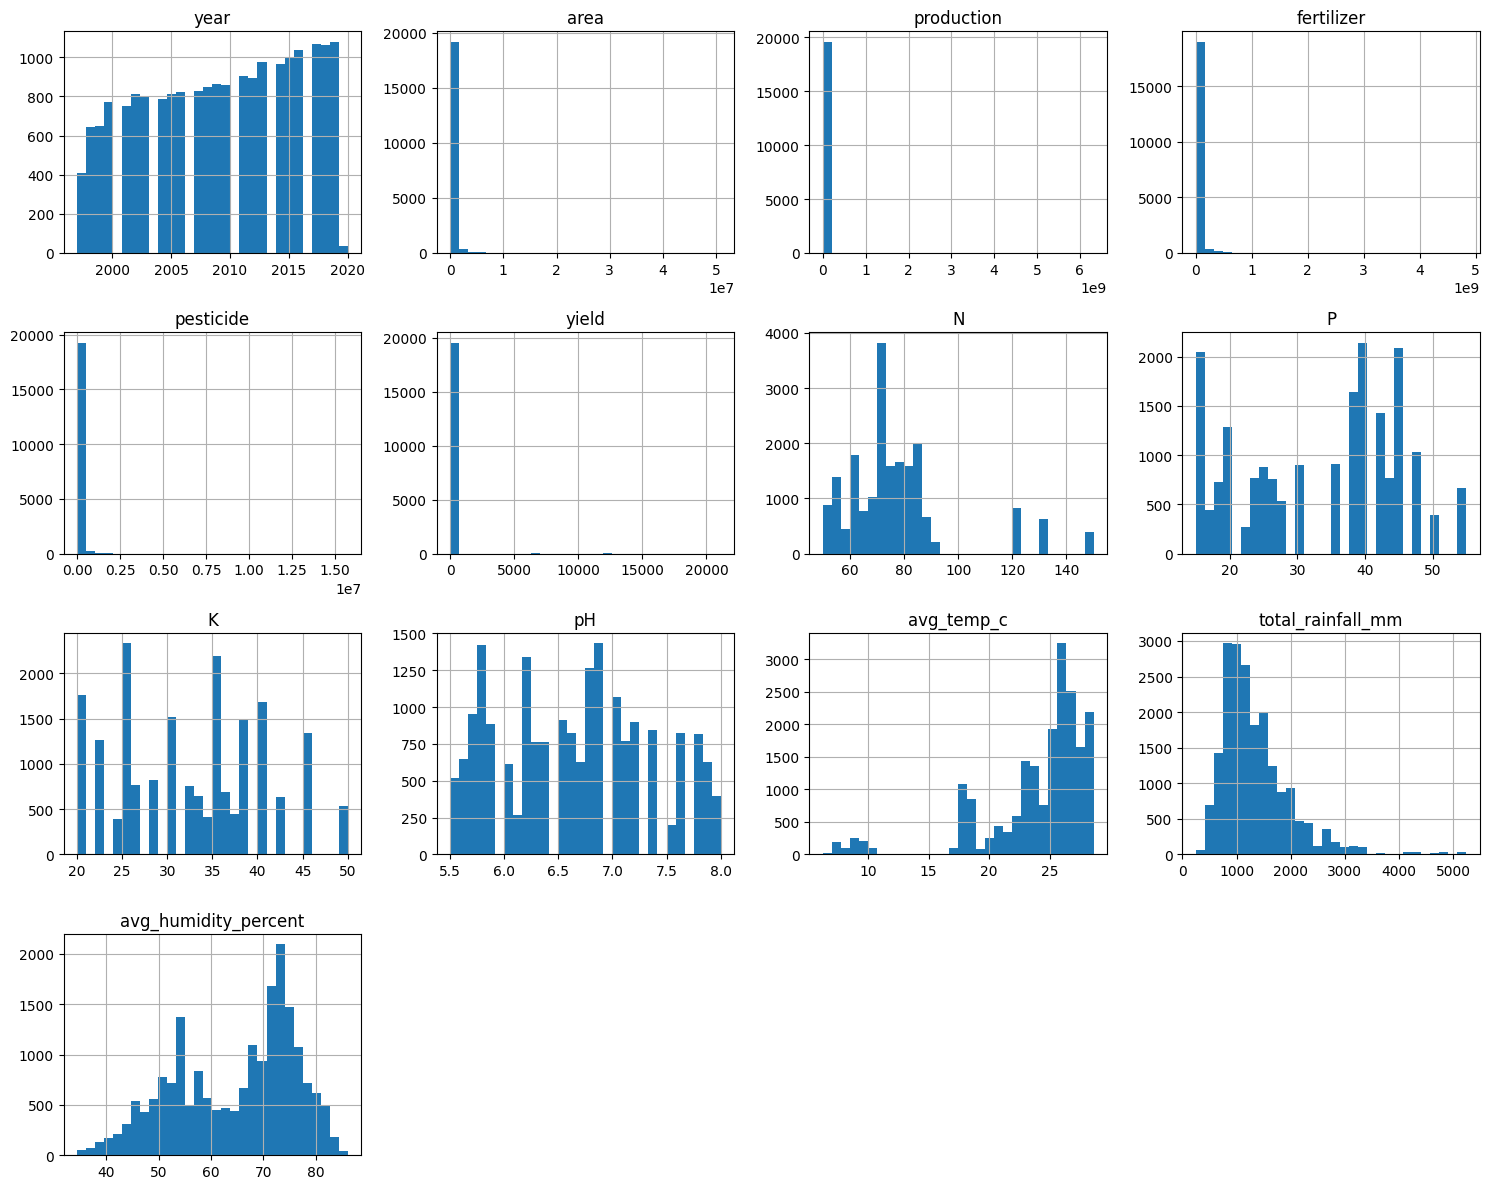

In [29]:
master_df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

### Observation

The numerical features show different distributions. Area, production, fertilizer, pesticide, yield, and rainfall are highly right-skewed, with a small number of observations having very large values. The soil and weather variables show more varied distributions across their ranges. These patterns and potential extreme values will be considered during preprocessing.

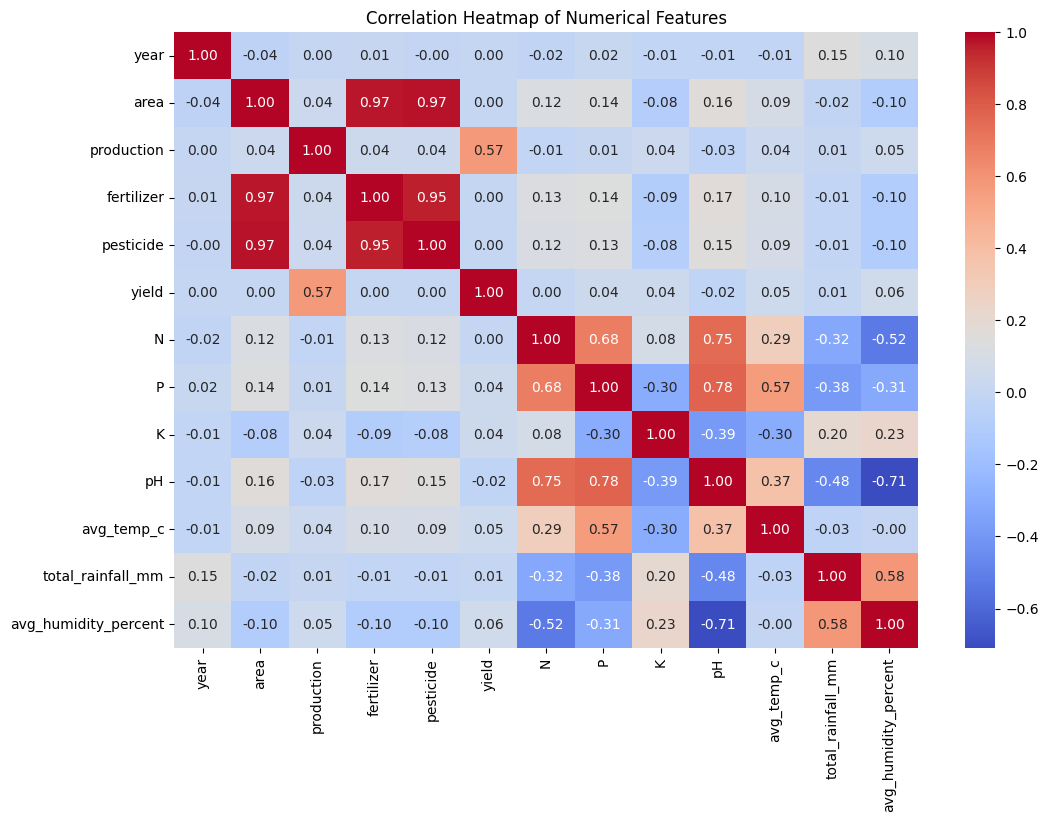

In [30]:
# Calculate correlations between numerical features
correlation = master_df.select_dtypes(include='number').corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

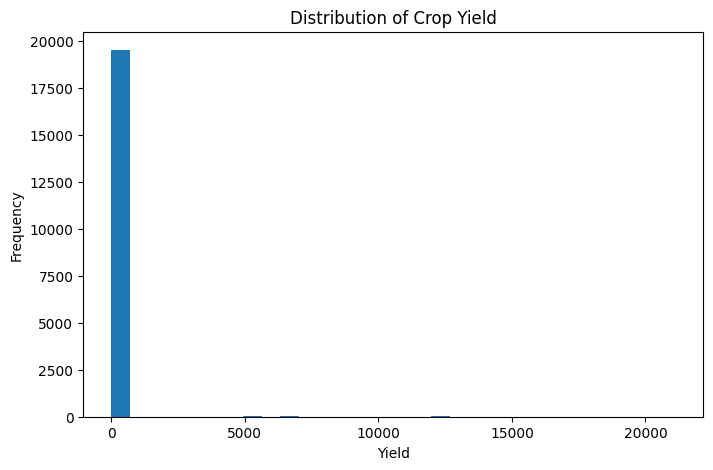

In [31]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))

plt.hist(master_df['yield'], bins=30)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

#yield is what our regression model will predict, so we want to clearly understand its distribution and extreme values.

### Observation

The crop yield distribution is highly right-skewed. Most yield values are concentrated at the lower end, while a small number of observations have extremely high values. This indicates the presence of potential outliers and will be considered during preprocessing and regression modeling.

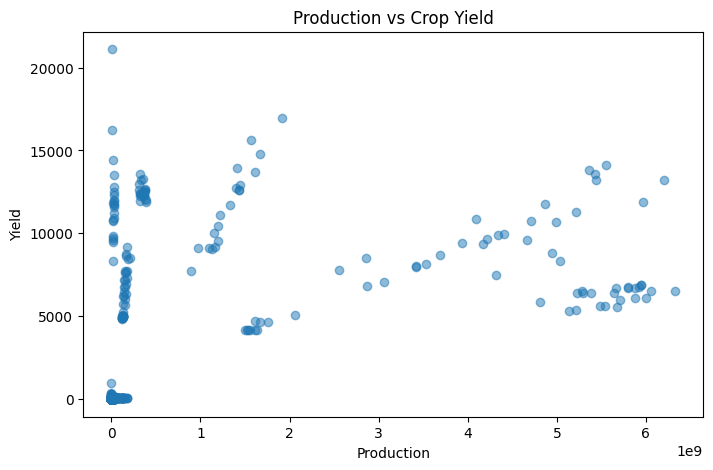

In [32]:
# Plot production against crop yield
plt.figure(figsize=(8, 5))

plt.scatter(master_df['production'], master_df['yield'], alpha=0.5)

plt.title("Production vs Crop Yield")
plt.xlabel("Production")
plt.ylabel("Yield")

plt.show()

### Observation

The scatter plot shows a generally positive relationship between production and crop yield. However, the observations are widely scattered and include some extreme values, indicating that the relationship is not strictly linear. These extreme values will be considered during preprocessing.

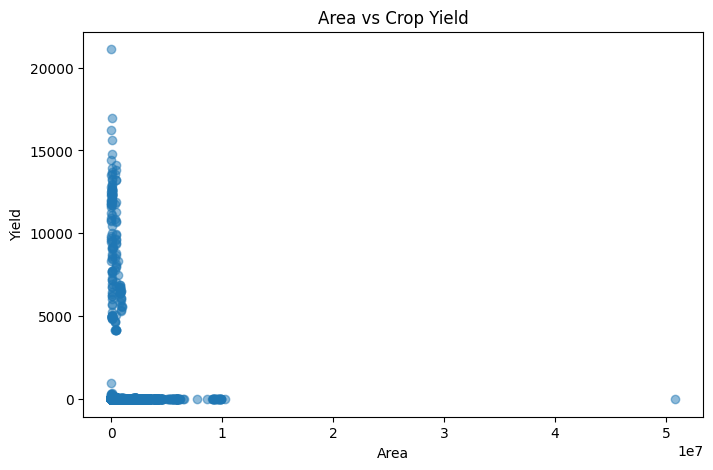

In [33]:
# Plot area against crop yield
plt.figure(figsize=(8, 5))

plt.scatter(master_df['area'], master_df['yield'], alpha=0.5)

plt.title("Area vs Crop Yield")
plt.xlabel("Area")
plt.ylabel("Yield")

plt.show()

### Observation

The scatter plot shows no clear strong linear relationship between cultivated area and crop yield. Most observations are concentrated at lower area and yield values, while a few observations have extremely large area values. The wide spread of points and extreme values indicate that area alone may not strongly explain variations in crop yield.

## 3. Preprocessing and Feature Engineering

The dataset is prepared for regression modeling by handling categorical variables, checking and treating outliers, creating useful derived features, and preparing the data for model training. The data is split into training and testing sets, and numerical features are scaled where required.

In [44]:
# Check missing values
print("Missing values:")
print(master_df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", master_df.duplicated().sum())

Missing values:
crop                    0
year                    0
season                  0
state                   0
area                    0
production              0
fertilizer              0
pesticide               0
yield                   0
N                       0
P                       0
K                       0
pH                      0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
dtype: int64

Duplicate rows: 0


In [45]:
#Train,Test and Split the data

from sklearn.model_selection import train_test_split

# Separate features and target
X = master_df.drop('yield', axis=1)
y = master_df['yield']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15751, 15)
Testing data: (3938, 15)


In [46]:
outlier_cols = [
    'area',
    'production',
    'fertilizer',
    'pesticide',
    'avg_temp_c',
    'total_rainfall_mm'
]

# Treat outliers using training data only
for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

print("Outlier treatment completed.")

Outlier treatment completed.


In [49]:
# Create fertilizer usage per unit area
#How much fertilizer is used relative to the cultivated area.
X_train['fertilizer_per_area'] = (
    X_train['fertilizer'] / X_train['area'].replace(0, np.nan)
)

X_test['fertilizer_per_area'] = (
    X_test['fertilizer'] / X_test['area'].replace(0, np.nan)
)

print("Feature engineering completed.")
print("New feature: fertilizer_per_area")

Feature engineering completed.
New feature: fertilizer_per_area


In [50]:
print(X_train[['fertilizer', 'area', 'fertilizer_per_area']].head())

         fertilizer       area  fertilizer_per_area
19466  5.980464e+04     357.00           167.520000
17802  1.000500e+04      75.00           133.400000
7014   2.165052e+04     204.00           106.130000
14078  3.178312e+06   21054.00           150.960000
8121   2.467612e+07  185513.25           133.015413


### Feature Engineering

A new feature, `fertilizer_per_area`, was created by dividing fertilizer usage by cultivated area. This feature represents fertilizer usage relative to the size of the cultivated area and may provide additional information for predicting crop yield.

In [ ]:
#Checking the new feature
print("Missing values in fertilizer_per_area:")
print(X_train['fertilizer_per_area'].isnull().sum())

print(X_test['fertilizer_per_area'].isnull().sum())

Missing values in fertilizer_per_area:
0
0


In [53]:
categorical_cols = [
    'crop',
    'season',
    'state'
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Categorical features:
['crop', 'season', 'state']

Numerical features:
['year', 'area', 'production', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'fertilizer_per_area']


In [54]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoder.fit(X_train[categorical_cols])

print("Encoding completed.")

Encoding completed.


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])
print("Scaling completed.")

Scaling completed.


In [57]:
# Transform categorical features
X_train_cat = encoder.transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# Transform numerical features
X_train_num = scaler.transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

In [58]:
import numpy as np

X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat
])

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (15751, 104)
Processed testing data: (3938, 104)


In [59]:
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

print("\nTarget training shape:", y_train.shape)
print("Target testing shape:", y_test.shape)

Training shape: (15751, 104)
Testing shape: (3938, 104)

Target training shape: (15751,)
Target testing shape: (3938,)


## Part 3 — Preprocessing Summary

The dataset was checked for missing values and duplicate rows, and no missing values or duplicates were found. Potential outliers in selected numerical features were treated using IQR-based capping, with limits calculated from the training data only. The dataset was divided into training and testing sets using an 80:20 split with random_state=42. A new `fertilizer_per_area` feature was engineered to represent fertilizer usage relative to cultivated area. Categorical features were converted using one-hot encoding, while numerical features were standardized using StandardScaler. Both the encoder and scaler were fitted only on the training data to prevent data leakage.